In [37]:
import pandas as pd
import pulp
import haversine as hv
import copy

In [38]:
coord = pd.read_csv('Varanasi_PDP.csv')
coord

,Location,Lat,Long,Pickups,Delivery
0,IP Sigra mall(Depot),25.317284,82.990098,0,0
1,Mech dept,25.261696,82.991828,0,68
2,Sarnath,25.371556,83.025211,34,2
3,Sankat Mochan,25.285488,83.000301,56,36
4,VT BHU,25.266026,82.988330,47,96
5,Kashi Vishwanath Temple,25.308826,83.009428,0,81
6,Susuwahi,25.255879,82.974239,42,32
7,JHV mall,25.335669,82.977444,0,87
8,Lanka,25.281364,82.997783,49,80
9,Manduadih,25.296840,82.970123,62,5


In [40]:
dis_mat = [[hv.haversine((coord.loc[i]['Lat'],coord.loc[i]['Long']), (coord.loc[j]['Lat'],coord.loc[j]['Long']),unit = hv.Unit.KILOMETERS) for j in coord.index] for i in coord.index]
m=pd.DataFrame(dis_mat)
m

,0,1,2,3,4,5,6,7,8,9
0,0.000000,6.183598,6.990671,3.681315,5.702464,2.158675,7.011689,2.407650,4.068138,3.033119
1,6.183598,0.000000,12.668409,2.779414,0.596249,5.531388,1.883358,8.351610,2.267548,4.476010
2,6.990671,12.668409,0.000000,9.892373,12.306094,7.153300,13.845653,6.241973,10.400862,9.983768
3,3.681315,2.779414,9.892373,0.000000,2.476361,2.752526,4.208079,6.034386,0.523800,3.286173
4,5.702464,0.596249,12.306094,2.476361,0.000000,5.210546,1.811361,7.820961,1.952564,3.884844
5,2.158675,5.531388,7.153300,2.752526,5.210546,0.000000,6.868838,4.386750,3.270372,4.170026
6,7.011689,1.883358,13.845653,4.208079,1.811361,6.868838,0.000000,8.878163,3.692686,4.573514
7,2.407650,8.351610,6.241973,6.034386,7.820961,4.386750,8.878163,0.000000,6.375164,4.379843
8,4.068138,2.267548,10.400862,0.523800,1.952564,3.270372,3.692686,6.375164,0.000000,3.270348
9,3.033119,4.476010,9.983768,3.286173,3.884844,4.170026,4.573514,4.379843,3.270348,0.000000


In [41]:
import numpy as np
import itertools
from pulp import GUROBI

###----DEFINE PARAMETERS------###

depot = 'IP Sigra mall(Depot)' #Also Set Location Pickup/Delivery volume as zero in dataset to make as depot
dep = list(coord['Location']).index(depot)
vehicles = 4 # 2<=vehicles<=7
cap = 150  # Max. volume/space per vehicle
d = coord['Delivery'] #Delivery volume at each node, Update dataset to change
p = coord['Pickups'] #pickup volume at each node, Update dataset to change

#define model
vrp = pulp.LpProblem('VRP-PD',pulp.LpMinimize)

#define location pairs as routes
routes = [(i,j) if i!=j else None for i in coord.index for j in coord.index]

#define decision variable
#Route selection variable
x = {(route,v) : pulp.LpVariable('x_'+str(route)+str(v),cat = 'Binary') for route in routes for v in range(vehicles)}
#Pickup Load during each trip
PL = {(route,v) : pulp.LpVariable('PL_'+str(route)+str(v),cat = 'Continuous',lowBound = 0) for route in routes for v in range(vehicles)}
#Delivery load during each trip
DL = {(route,v) : pulp.LpVariable('DL_'+str(route)+str(v),cat = 'Continuous',lowBound = 0) for route in routes for v in range(vehicles)}


#define objective function
z = 0
for i in coord.index:
    for j in coord.index:
        if i!=j:
            for v in range(vehicles):
                z += x[(i,j),v]*dis_mat[i][j]
vrp += z

#define constraints

#Inflow per location == 1
for j in coord.index:
    if j != dep:
        vrp += pulp.lpSum(x[(i,j),v] if i!=j else None for i in coord.index for v in range(vehicles)) == 1

#every vehicle must depart from depot
for v in range(vehicles):
    vrp += pulp.lpSum(x[(dep,j),v] if j!=dep else None for j in coord.index) == 1

#Flow conservation for each location
for j in coord.index:
    for v in range(vehicles):
        vrp += pulp.lpSum(x[(i,j),v] if i!=j else None for i in coord.index) == pulp.lpSum(x[(j,i),v] if j!=i else None \
                                                                                           for i in coord.index)

#Load constraints
# # Delivery Load when starting from depot
for v in range(vehicles):
    vrp += pulp.lpSum(DL[(dep,j),v] if j!=dep else None for j in coord.index) >= pulp.lpSum(x[(i,j),v]*d[j] \
                                                                                            if i!=j and j!=dep else None \
                                                                                            for i in coord.index for j in coord.index)


# Load when reaching depot
    vrp += pulp.lpSum(DL[(i,dep),v] if i!=dep else None for i in coord.index) >= pulp.lpSum(x[(i,j),v]*p[i] if i!=j and i!=dep else None \
                                                                                            for i in coord.index for j in coord.index)
        

# Pickup Load + Delivery load at each edge <= capacity
for v in range(vehicles):
    for route in routes:
        vrp += PL[route,v] + DL[route,v] <= cap*x[route,v]
            

#Subtour elimination
subtours = []
for i in range(2,len(coord)):
    subtours += itertools.combinations(range(1,len(coord)), i)

for s in subtours:
    vrp += pulp.lpSum(x[(i,j),v] if i !=j else 0 \
                      for i, j in itertools.permutations(s,2) \
                      for v in range(vehicles)) <= len(s) - 1

#solve
vrp.solve(GUROBI())

Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (win64)

CPU model: Intel(R) Core(TM) i5-9300HF CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 963 rows, 1092 columns and 39756 nonzeros
Model fingerprint: 0xc4a517ad
Variable types: 728 continuous, 364 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [5e-01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+00]
Presolve removed 400 rows and 732 columns
Presolve time: 0.19s
Presolved: 563 rows, 360 columns, 38452 nonzeros
Variable types: 0 continuous, 360 integer (360 binary)

Root relaxation: objective 3.935791e+01, 114 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   39.35791    0   20          -   39.35791      -

1

In [43]:
z.value()

53.91558393888683

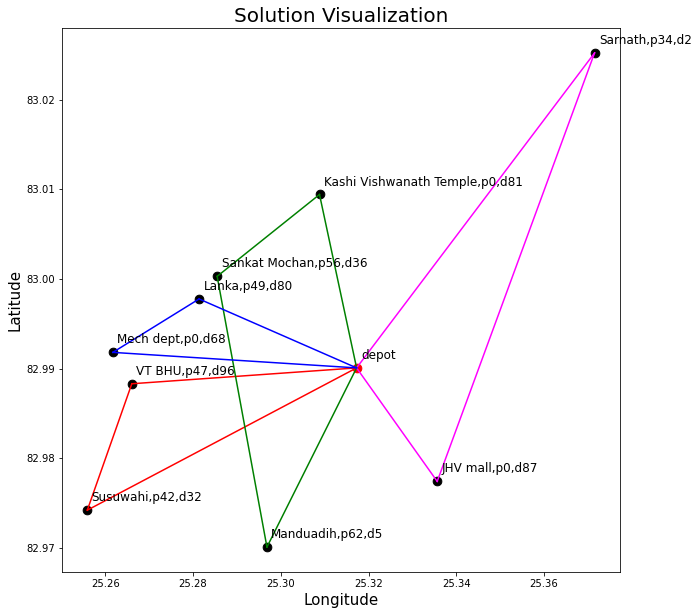

In [44]:
# Visualizing the solution
from matplotlib import pyplot as plt
plt.figure(figsize=(10,10))
colors = ['red','green','magenta','blue','black','yellow','cyan']
for i in coord.index:    
    if i==dep:
        plt.scatter(coord.Lat[i], coord.Long[i], c='red', s=75)
        plt.text(coord.Lat[i]+0.001, coord.Long[i]+0.001, "depot", fontsize=12)
    else:
        plt.scatter(coord.Lat[i], coord.Long[i], c='black', s=75)
        plt.text(coord.Lat[i]+0.001, coord.Long[i]+0.001, coord.loc[i]["Location"]+',p'+str(p[i])+',d'+str(d[i]), fontsize=12)
        plt.xlabel("Longitude",fontsize = 15)
        plt.ylabel("Latitude",fontsize = 15)
        plt.title("Solution Visualization",fontsize = 20)
        
for v in range(vehicles):
    for i in coord.index:
        for j in coord.index:
            if i != j and pulp.value(x[(i,j),v]) == 1.0:
                plt.plot([coord.Lat[i], coord.Lat[j]], [coord.Long[i], coord.Long[j]], c=colors[v])

In [45]:
# Routes of individual vehicle
# This function takes route plan as input and return the ordered routes and subtours, if present
import copy
def get_plan(r0,depot):
    print()
    r=copy.copy(r0)
    for iter in range(len(r)):
        if(coord.iloc[r[iter][0]]['Location']==depot):
            break
    route = []
    while len(r) != 0:
        plan = [r[iter]]
        del (r[iter])
        l = 0
        while len(plan) > l:
            l = len(plan)
            for i, j in enumerate(r):
                if plan[-1][1] == j[0]:
                    plan.append(j)
                    del (r[i])
        route.append(plan)
        iter = 0
    return(route)


routes_of_all_vehicles = []
for v in range(vehicles):
    route = []
    for i in coord.index:
        for j in coord.index:
            if(i!=j and x[(i,j),v].value()==1.0):
                route.append((i,j))
        
    print(f"\nRoute for Vehicle {v} is ---------------")
    print(get_plan(route,depot))
    routes_of_all_vehicles.append(get_plan(route,depot))


Route for Vehicle 0 is ---------------

[[(0, 6), (6, 4), (4, 0)]]


Route for Vehicle 1 is ---------------

[[(0, 5), (5, 3), (3, 9), (9, 0)]]


Route for Vehicle 2 is ---------------

[[(0, 2), (2, 7), (7, 0)]]


Route for Vehicle 3 is ---------------

[[(0, 8), (8, 1), (1, 0)]]

